Original Shape: (352, 352)
Original Unique: [0]
Resized Shape: (352, 352)
Resized Unique: [0]


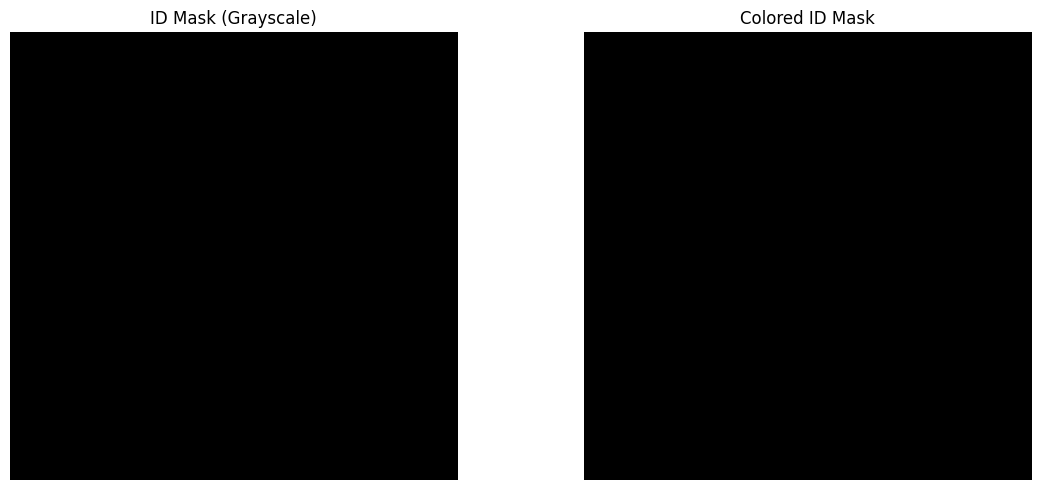

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

MASK_PATH = "./sublabels/sublabels_44/1.png"
H, W = 352, 352
NUM_CLASSES = 8

# ===== 讀取 ID mask =====
mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
print(f"Original Shape: {mask.shape}")
print(f"Original Unique: {np.unique(mask)}")

# ===== Resize（ID mask 一定用 NEAREST）=====
mask_resized = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
print(f"Resized Shape: {mask_resized.shape}")
print(f"Resized Unique: {np.unique(mask_resized)}")

# ===== Sanity check =====
assert mask_resized.min() >= 0 and mask_resized.max() < NUM_CLASSES, \
    "Mask contains invalid class IDs!"

# ===== Color map (8 classes) =====
COLOR_MAP = np.array([
    [0,   0,   0],     # 0 - black
    [255, 0,   0],     # 1 - red
    [0,   255, 0],     # 2 - green
    [0,   0,   255],   # 3 - blue
    [255, 255, 0],     # 4 - yellow
    [255, 0,   255],   # 5 - magenta
    [0,   255, 255],   # 6 - cyan
    [255, 255, 255],   # 7 - white
], dtype=np.uint8)

# ===== 填色 =====
color_mask = COLOR_MAP[mask_resized]   # (H, W, 3)

# ===== 顯示 =====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("ID Mask (Grayscale)")
plt.imshow(mask_resized, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Colored ID Mask")
plt.imshow(color_mask)
plt.axis("off")

plt.tight_layout()
plt.show()
